Base geral tratada carregada com sucesso.
Total de registros: 1020
Período: 2023-07-01 a 2026-04-15
Base inicial para GRU criada com sucesso.
Separação preliminar e normalização realizadas.
Sequências temporais (Multi-Input) criadas com sucesso.
X_train_seq: (900, 30, 12) | X_train_fut: (900, 11)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ historico           │ (None, 30, 12)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 32)        │      4,416 │ historico[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 32)        │          0 │ gru[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ calendario_futuro   │ (None, 11)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 43)        │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ calendario_futur… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │        704 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         17 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,137 (20.07 KB)

 Trainable params: 5,137 (20.07 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0658 - val_loss: 0.0064
Epoch 2/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0194 - val_loss: 0.0055
Epoch 3/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0146 - val_loss: 0.0063
Epoch 4/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0121 - val_loss: 0.0050
Epoch 5/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0101 - val_loss: 0.0053
Epoch 6/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0089 - val_loss: 0.0064
Epoch 7/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0078 - val_loss: 0.0068
Epoch 8/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0079 - val_loss: 0.0075
Epoch 9/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0071 - val_loss: 0.0063
Epoch 10/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0064 - val_loss: 0.0054
Epoch 11/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0058 - val_loss: 0.0049
Epoch 12/200
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0

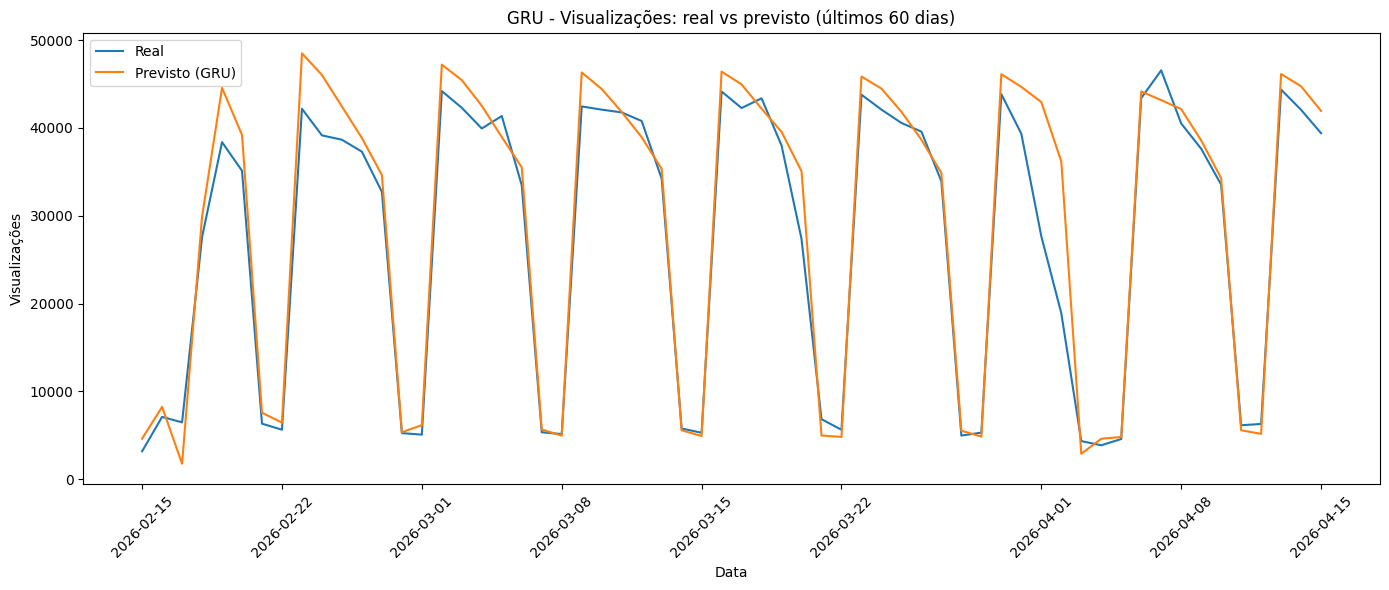

Arquivos salvos com sucesso:
../dados/metricas_gru.csv
../dados/previsao_gru_visualizacoes.csv

MÉTRICAS GRU PARA COMPARAÇÃO
RMSE: 3987.37
MAE : 2540.11
MAPE: 12.76%
R²  : 0.9404

Arquivos CSV gerados com sucesso no diretório atual.


In [1]:
# %% [markdown]
# ## 1. Geração da base específica para a rede neural GRU
# 
# Nesta etapa, a base geral tratada é carregada a partir do arquivo `trafego_tratado.csv`. A partir dela, será construída uma base específica para a rede neural GRU.

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GRU, Dense, Dropout, Concatenate
from tensorflow.keras.callbacks import EarlyStopping

# ============================================================
# 1. Leitura da base geral tratada
# ============================================================

df = pd.read_csv("../dados/trafego_tratado.csv")

# Converte a coluna de data
df["Data"] = pd.to_datetime(df["Data"])

# Garante ordenação cronológica
df = df.sort_values("Data").reset_index(drop=True)

print("Base geral tratada carregada com sucesso.")
print(f"Total de registros: {len(df)}")
print(f"Período: {df['Data'].min().date()} a {df['Data'].max().date()}")

# %% [markdown]
# ## 2. Seleção das variáveis para a base da GRU
# 
# Nesta etapa, são selecionadas as variáveis que serão utilizadas pela rede neural GRU. A variável principal continua sendo `Visualizações`. 
# Variáveis como `Sessões` e `Usuários ativos` foram removidas, pois não são conhecidas no futuro.

# %%
df_gru = df.copy()

colunas_gru = [
    "Data",
    "Visualizações",
    "dia_semana",
    "fim_de_semana",
    "mes",
    "recesso_judiciario",
    "feriado_nacional_fixo",
    "carnaval",
    "quarta_cinzas",
    "sexta_paixao",
    "corpus_christi",
    "data_especifica_judiciario",
    "ponto_facultativo_emenda"
]

df_gru = df_gru[colunas_gru].copy()

df_gru.to_csv("../dados/trafego_gru_visualizacoes.csv", index=False)

print("Base inicial para GRU criada com sucesso.")

# %% [markdown]
# ## 3. Separação preliminar e normalização dos dados
# 
# A base foi dividida estritamente de forma cronológica em Treino, Validação e Teste.
# A criação de um conjunto de validação físico (em vez de usar validation_split dinâmico) elimina o risco de vazamento de dados (*data leakage*) gerado pela sobreposição das janelas temporais.

# %%
dias_teste = 60
dias_val = 30
janela = 30

colunas_modelo = [
    "Visualizações",
    "dia_semana",
    "fim_de_semana",
    "mes",
    "recesso_judiciario",
    "feriado_nacional_fixo",
    "carnaval",
    "quarta_cinzas",
    "sexta_paixao",
    "corpus_christi",
    "data_especifica_judiciario",
    "ponto_facultativo_emenda"
]
dados_modelo = df_gru[colunas_modelo].copy()

idx_alvo = colunas_modelo.index("Visualizações")

# Fatiamento rigoroso para garantir que as janelas de um conjunto não invadam o outro
dados_treino = dados_modelo.iloc[:-(dias_teste + dias_val)].copy()
dados_val = dados_modelo.iloc[-(dias_teste + dias_val + janela):-dias_teste].copy()
dados_teste = dados_modelo.iloc[-(dias_teste + janela):].copy()

datas_teste_gru = df_gru["Data"].iloc[-dias_teste:].copy()

# Normalização ajustada apenas no treino
scaler = MinMaxScaler()
dados_treino_scaled = scaler.fit_transform(dados_treino)
dados_val_scaled = scaler.transform(dados_val)
dados_teste_scaled = scaler.transform(dados_teste)

print("Separação preliminar e normalização realizadas.")

# %% [markdown]
# ## 4. Criação das sequências temporais (Múltiplas Entradas)
# 
# A função de sequenciamento separa os dados em duas estruturas para cada dia `i`:
# 1. O histórico dos últimos 30 dias (todas as variáveis).
# 2. O calendário do próprio dia que será previsto (todas as variáveis exógenas).

# %%
def criar_sequencias_multi_input(dados, janela, idx_alvo):
    X_seq, X_futuro, y = [], [], []
    
    n_features = dados.shape[1]
    idx_exog = [i for i in range(n_features) if i != idx_alvo]
    
    for i in range(janela, len(dados)):
        X_seq.append(dados[i-janela:i, :])
        X_futuro.append(dados[i, idx_exog])
        y.append(dados[i, idx_alvo])

    return np.array(X_seq), np.array(X_futuro), np.array(y)

# Sequências de treino
X_train_seq, X_train_fut, y_train_gru = criar_sequencias_multi_input(dados_treino_scaled, janela, idx_alvo)

# Sequências de validação
X_val_seq, X_val_fut, y_val_gru = criar_sequencias_multi_input(dados_val_scaled, janela, idx_alvo)

# Sequências de teste
X_test_seq, X_test_fut, y_test_gru = criar_sequencias_multi_input(dados_teste_scaled, janela, idx_alvo)

print("Sequências temporais (Multi-Input) criadas com sucesso.")
print(f"X_train_seq: {X_train_seq.shape} | X_train_fut: {X_train_fut.shape}")

# %% [markdown]
# ## 5. Construção da rede neural GRU (API Funcional)
# 
# A arquitetura utiliza a API Funcional do Keras para receber dois fluxos de dados paralelos. A camada GRU processa a janela histórica e, em seguida, seu resultado é concatenado com as variáveis exógenas do dia alvo antes de passar pelas camadas densas finais.

# %%
np.random.seed(42)
tf.random.set_seed(42)

n_timesteps = X_train_seq.shape[1]
n_features_seq = X_train_seq.shape[2]
n_features_fut = X_train_fut.shape[1]

# Ramo 1: Processamento da sequência histórica
entrada_seq = Input(shape=(n_timesteps, n_features_seq), name="historico")
gru_out = GRU(32, activation="tanh")(entrada_seq)
gru_out = Dropout(0.2)(gru_out)

# Ramo 2: Dados de calendário do dia da previsão
entrada_futuro = Input(shape=(n_features_fut,), name="calendario_futuro")

# Concatenação e Camadas Densas
concat = Concatenate()([gru_out, entrada_futuro])
densa = Dense(16, activation="relu")(concat)
saida = Dense(1)(densa)

modelo_gru = Model(inputs=[entrada_seq, entrada_futuro], outputs=saida)

modelo_gru.compile(
    optimizer="adam",
    loss="mse"
)

modelo_gru.summary()

# %% [markdown]
# ## 6. Treinamento da rede neural GRU
# 
# Treinamento utilizando o conjunto de validação explícito e parada antecipada.

# %%
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=20,
    restore_best_weights=True
)

historico_gru = modelo_gru.fit(
    x=[X_train_seq, X_train_fut],
    y=y_train_gru,
    validation_data=([X_val_seq, X_val_fut], y_val_gru),
    epochs=200,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

print("Treinamento concluído.")

# %% [markdown]
# ## 7. Avaliação da GRU no conjunto de teste

# %%
def calcular_mape(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    mascara = y_true != 0
    return np.mean(np.abs((y_true[mascara] - y_pred[mascara]) / y_true[mascara])) * 100

def inverter_escala_alvo(valores_normalizados, scaler, idx_alvo, n_features):
    matriz_auxiliar = np.zeros((len(valores_normalizados), n_features))
    matriz_auxiliar[:, idx_alvo] = valores_normalizados.reshape(-1)
    valores_originais = scaler.inverse_transform(matriz_auxiliar)[:, idx_alvo]
    return valores_originais

# Previsão normalizada (exige as duas entradas)
y_pred_gru_scaled = modelo_gru.predict([X_test_seq, X_test_fut])

# Reconversão para a escala original
y_test_gru_original = inverter_escala_alvo(y_test_gru, scaler, idx_alvo, len(colunas_modelo))
y_pred_gru_original = inverter_escala_alvo(y_pred_gru_scaled, scaler, idx_alvo, len(colunas_modelo))

rmse_gru = np.sqrt(mean_squared_error(y_test_gru_original, y_pred_gru_original))
mae_gru = mean_absolute_error(y_test_gru_original, y_pred_gru_original)
mape_gru = calcular_mape(y_test_gru_original, y_pred_gru_original)
r2_gru = r2_score(y_test_gru_original, y_pred_gru_original)

print("=" * 60)
print("AVALIAÇÃO GRU - ÚLTIMOS 60 DIAS")
print("=" * 60)
print(f"RMSE: {rmse_gru:.2f}")
print(f"MAE : {mae_gru:.2f}")
print(f"MAPE: {mape_gru:.2f}%")
print(f"R²  : {r2_gru:.4f}")

# %% [markdown]
# ## 8. Visualização dos valores reais e previstos pela GRU

# %%
plt.figure(figsize=(14, 6))
plt.plot(datas_teste_gru.values, y_test_gru_original, label="Real")
plt.plot(datas_teste_gru.values, y_pred_gru_original, label="Previsto (GRU)")

plt.title("GRU - Visualizações: real vs previsto (últimos 60 dias)")
plt.xlabel("Data")
plt.ylabel("Visualizações")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 9. Salvamento das métricas e previsões da GRU

# %%
metricas_gru = pd.DataFrame({
    "modelo": ["GRU"],
    "rmse": [rmse_gru],
    "mae": [mae_gru],
    "mape": [mape_gru],
    "r2": [r2_gru]
})

metricas_gru.to_csv("../dados/metricas_gru.csv", index=False)

previsao_gru = pd.DataFrame({
    "Data": datas_teste_gru.values,
    "real": y_test_gru_original,
    "previsto_gru": y_pred_gru_original
})

previsao_gru["erro"] = previsao_gru["real"] - previsao_gru["previsto_gru"]
previsao_gru["erro_absoluto"] = abs(previsao_gru["erro"])
previsao_gru["erro_percentual_abs"] = (previsao_gru["erro_absoluto"] / previsao_gru["real"]) * 100

previsao_gru.to_csv("../dados/previsao_gru_visualizacoes.csv", index=False)

print("Arquivos salvos com sucesso:")
print("../dados/metricas_gru.csv")
print("../dados/previsao_gru_visualizacoes.csv")

# Force o print separadamente
print("\n" + "=" * 40)
print("MÉTRICAS GRU PARA COMPARAÇÃO")
print("=" * 40)
print(f"RMSE: {rmse_gru:.2f}")
print(f"MAE : {mae_gru:.2f}")
print(f"MAPE: {mape_gru:.2f}%")
print(f"R²  : {r2_gru:.4f}")
print("=" * 40 + "\n")

# Remova o "../dados/" para salvar na mesma pasta onde o script está rodando e evitar falha
metricas_gru.to_csv("metricas_gru.csv", index=False)
previsao_gru.to_csv("previsao_gru_visualizacoes.csv", index=False)

print("Arquivos CSV gerados com sucesso no diretório atual.")